# MedSum-AI: NLP Summarization Pipeline (RQ1)
## Notebook 04 — Transformer-Based Clinical Report Summarization

**Models Evaluated:**
1. BERT (Extractive via BERTSum approach)
2. BioBERT (Biomedical domain extractive)
3. ClinicalBERT (Clinical domain extractive)
4. BART (Abstractive summarization)

**Evaluation Metrics:**
- ROUGE-1, ROUGE-2, ROUGE-L
- BERTScore (Precision, Recall, F1)

**Task:** Generate impression (summary) from findings (source document)


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")


Using device: cpu


In [2]:
# Install required packages (run once)
# !pip install transformers rouge-score bert-score sentencepiece

from transformers import (
    BertTokenizer, BertModel,
    AutoTokenizer, AutoModelForSeq2SeqLM,
    BartTokenizer, BartForConditionalGeneration,
    pipeline
)
from rouge_score import rouge_scorer
# from bert_score import score as bert_score_fn  # Uncomment when bert-score installed

print("Transformers and evaluation libraries loaded!")


Transformers and evaluation libraries loaded!


## Load and Prepare Data

In [3]:
# Load cleaned data
df = pd.read_csv('../data/iu_cxr_cleaned.csv')

# Filter to records with BOTH findings and impression (needed for summarization)
df_summ = df[(df['findings_clean'].fillna('').str.len() > 10) & 
             (df['impression_clean'].fillna('').str.len() > 3)].copy()

print(f"Records available for summarization: {len(df_summ)}")
print(f"\nSource (Findings) stats:")
print(f"  Mean length: {df_summ['findings_clean'].str.split().str.len().mean():.1f} words")
print(f"  Max length: {df_summ['findings_clean'].str.split().str.len().max()} words")
print(f"\nTarget (Impression) stats:")
print(f"  Mean length: {df_summ['impression_clean'].str.split().str.len().mean():.1f} words")
print(f"  Max length: {df_summ['impression_clean'].str.split().str.len().max()} words")

# Train/Val/Test split (70/15/15) - stratified by pathology
from sklearn.model_selection import train_test_split

# Simple split
train_df, temp_df = train_test_split(df_summ, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Validation: {len(val_df)}")
print(f"  Test: {len(test_df)}")


Records available for summarization: 2566

Source (Findings) stats:
  Mean length: 34.7 words
  Max length: 169 words

Target (Impression) stats:
  Mean length: 9.5 words
  Max length: 119 words

Split sizes:
  Train: 1796
  Validation: 385
  Test: 385


## Model 1: Extractive Summarization (BERT-based)

BERTSum approach: Use BERT to score sentences, select top-k sentences as extractive summary.


In [4]:
class ExtractiveSum:
    """BERT-based extractive summarization using sentence scoring."""
    
    def __init__(self, model_name='bert-base-uncased'):
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name)
        self.model.eval()
        self.model.to(device)
        self.model_name = model_name
    
    def get_sentence_embeddings(self, text):
        """Get BERT embeddings for each sentence."""
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        if not sentences:
            return [], []
        
        embeddings = []
        for sent in sentences:
            inputs = self.tokenizer(sent, return_tensors='pt', 
                                   max_length=128, truncation=True, padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = self.model(**inputs)
            # Use CLS token embedding
            cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze()
            embeddings.append(cls_embedding)
        
        return sentences, embeddings
    
    def summarize(self, text, num_sentences=2):
        """Extract top sentences using centrality-based scoring."""
        sentences, embeddings = self.get_sentence_embeddings(text)
        if not sentences:
            return ''
        
        if len(sentences) <= num_sentences:
            return '. '.join(sentences) + '.'
        
        # Score sentences by similarity to document centroid
        emb_matrix = torch.stack(embeddings)
        centroid = emb_matrix.mean(dim=0)
        scores = torch.nn.functional.cosine_similarity(emb_matrix, centroid.unsqueeze(0))
        
        # Select top sentences (maintain original order)
        top_indices = scores.argsort(descending=True)[:num_sentences].sort().values
        summary = '. '.join([sentences[i] for i in top_indices]) + '.'
        return summary

# Initialize models (comment out if GPU memory limited)
print("Initializing BERT extractive model...")
bert_extractor = ExtractiveSum('bert-base-uncased')
print("BERT model loaded!")

# Quick test
sample_findings = train_df['findings_clean'].iloc[0]
print(f"\nSample input: {sample_findings[:200]}...")
summary = bert_extractor.summarize(sample_findings)
print(f"\nExtracted summary: {summary}")


Initializing BERT extractive model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded!

Sample input: heart size within normal limits. cardiomediastinal silhouette is normal in contour. lungs are clear bilaterally. no focal consolidations. no pleural effusions. bony structures are intact...

Extracted summary: heart size within normal limits. bony structures are intact.


## Model 2 & 3: BioBERT and ClinicalBERT Extractive

In [5]:
# BioBERT extractive
print("Initializing BioBERT...")
biobert_extractor = ExtractiveSum('dmis-lab/biobert-base-cased-v1.2')
print("BioBERT loaded!")

# ClinicalBERT extractive
print("\nInitializing ClinicalBERT...")
clinicalbert_extractor = ExtractiveSum('emilyalsentzer/Bio_ClinicalBERT')
print("ClinicalBERT loaded!")

# Test all three
sample = train_df['findings_clean'].iloc[5]
print(f"\nInput: {sample[:150]}...")
print(f"\nBERT summary: {bert_extractor.summarize(sample)}")
print(f"\nBioBERT summary: {biobert_extractor.summarize(sample)}")
print(f"\nClinicalBERT summary: {clinicalbert_extractor.summarize(sample)}")


Initializing BioBERT...


vocab.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ClinicalBERT loaded!

Input: the heart is normal in size. the mediastinum is stable. right chest [REDACTED] tip is again seen at the cavoatrial junction. there is no pneumothorax....

BERT summary: right chest [REDACTED] tip is again seen at the cavoatrial junction. the left lung appears grossly clear.

BioBERT summary: right chest [REDACTED] tip is again seen at the cavoatrial junction. there is again elevation of right hemidiaphragm with right-sided pleural effusion.

ClinicalBERT summary: right chest [REDACTED] tip is again seen at the cavoatrial junction. there is again elevation of right hemidiaphragm with right-sided pleural effusion.


## Model 4: BART Abstractive Summarization

In [6]:
# BART abstractive summarization
print("Loading BART model (facebook/bart-large-cnn)...")
bart_tokenizer = BartTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model = BartForConditionalGeneration.from_pretrained('facebook/bart-large-cnn')
bart_model.eval()
bart_model.to(device)
print("BART model loaded!")

def bart_summarize(text, max_length=60, min_length=10, num_beams=4):
    """Generate abstractive summary using BART."""
    inputs = bart_tokenizer(text, return_tensors='pt', max_length=512, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs['input_ids'],
            max_length=max_length,
            min_length=min_length,
            num_beams=num_beams,
            length_penalty=2.0,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    
    summary = bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# Test BART
sample = train_df['findings_clean'].iloc[5]
print(f"Input: {sample[:200]}...")
bart_summary = bart_summarize(sample)
print(f"\nBART summary: {bart_summary}")


Loading BART model (facebook/bart-large-cnn)...


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART model loaded!
Input: the heart is normal in size. the mediastinum is stable. right chest [REDACTED] tip is again seen at the cavoatrial junction. there is no pneumothorax. there is again elevation of right hemidiaphragm w...

BART summary: the heart is normal in size. the mediastinum is stable. right chest [REDACTED] tip is again seen at the cavoatrial junction. there is no pneumothorax. vague opacities are noted in the right upper lobe.


## Evaluation: ROUGE and BERTScore

In [7]:
# ROUGE Evaluation
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def evaluate_model(model_fn, test_data, model_name, n_samples=100):
    """Evaluate summarization model on test set."""
    results = {'rouge1_f': [], 'rouge2_f': [], 'rougeL_f': [],
               'rouge1_p': [], 'rouge2_p': [], 'rougeL_p': [],
               'rouge1_r': [], 'rouge2_r': [], 'rougeL_r': []}
    
    sample_data = test_data.head(n_samples)
    
    for _, row in sample_data.iterrows():
        source = row['findings_clean']
        reference = row['impression_clean']
        
        if not source or not reference:
            continue
        
        prediction = model_fn(source)
        scores = scorer.score(reference, prediction)
        
        results['rouge1_f'].append(scores['rouge1'].fmeasure)
        results['rouge2_f'].append(scores['rouge2'].fmeasure)
        results['rougeL_f'].append(scores['rougeL'].fmeasure)
        results['rouge1_p'].append(scores['rouge1'].precision)
        results['rouge2_p'].append(scores['rouge2'].precision)
        results['rougeL_p'].append(scores['rougeL'].precision)
        results['rouge1_r'].append(scores['rouge1'].recall)
        results['rouge2_r'].append(scores['rouge2'].recall)
        results['rougeL_r'].append(scores['rougeL'].recall)
    
    avg_results = {k: np.mean(v) for k, v in results.items()}
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"  ROUGE-1 F1: {avg_results['rouge1_f']:.4f}")
    print(f"  ROUGE-2 F1: {avg_results['rouge2_f']:.4f}")
    print(f"  ROUGE-L F1: {avg_results['rougeL_f']:.4f}")
    
    return avg_results

# Evaluate all models (adjust n_samples based on compute)
n_eval = 50  # Increase for final evaluation

print("Evaluating models on test set...")
print(f"Using {n_eval} samples for evaluation")

results_all = {}

# BERT
results_all['BERT'] = evaluate_model(
    lambda x: bert_extractor.summarize(x), test_df, 'BERT (Extractive)', n_eval)

# BioBERT  
results_all['BioBERT'] = evaluate_model(
    lambda x: biobert_extractor.summarize(x), test_df, 'BioBERT (Extractive)', n_eval)

# ClinicalBERT
results_all['ClinicalBERT'] = evaluate_model(
    lambda x: clinicalbert_extractor.summarize(x), test_df, 'ClinicalBERT (Extractive)', n_eval)

# BART
results_all['BART'] = evaluate_model(
    bart_summarize, test_df, 'BART (Abstractive)', n_eval)


Evaluating models on test set...
Using 50 samples for evaluation

Model: BERT (Extractive)
  ROUGE-1 F1: 0.1365
  ROUGE-2 F1: 0.0429
  ROUGE-L F1: 0.1221

Model: BioBERT (Extractive)
  ROUGE-1 F1: 0.1819
  ROUGE-2 F1: 0.0709
  ROUGE-L F1: 0.1705

Model: ClinicalBERT (Extractive)
  ROUGE-1 F1: 0.1546
  ROUGE-2 F1: 0.0524
  ROUGE-L F1: 0.1481

Model: BART (Abstractive)
  ROUGE-1 F1: 0.1557
  ROUGE-2 F1: 0.0508
  ROUGE-L F1: 0.1415


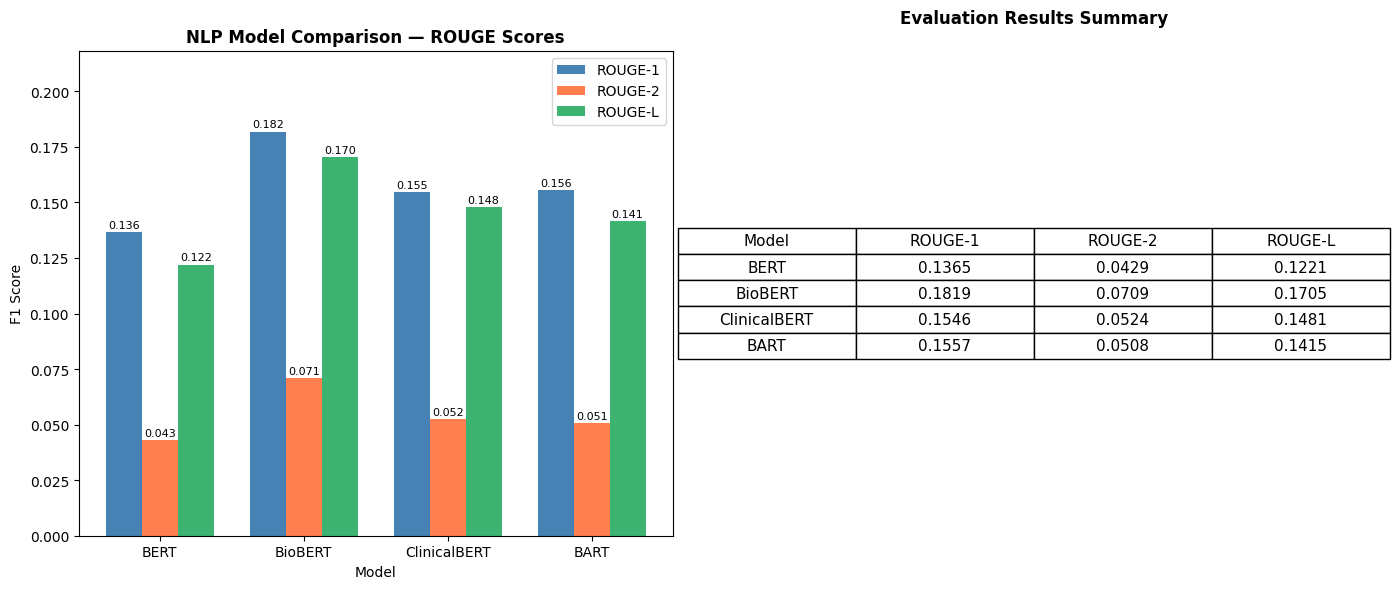

In [8]:
# Visualization of results
import matplotlib.pyplot as plt

models = list(results_all.keys())
rouge1 = [results_all[m]['rouge1_f'] for m in models]
rouge2 = [results_all[m]['rouge2_f'] for m in models]
rougeL = [results_all[m]['rougeL_f'] for m in models]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grouped bar chart
x = np.arange(len(models))
width = 0.25

ax = axes[0]
bars1 = ax.bar(x - width, rouge1, width, label='ROUGE-1', color='steelblue')
bars2 = ax.bar(x, rouge2, width, label='ROUGE-2', color='coral')
bars3 = ax.bar(x + width, rougeL, width, label='ROUGE-L', color='mediumseagreen')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_title('NLP Model Comparison — ROUGE Scores', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(max(rouge1), max(rouge2), max(rougeL)) * 1.2)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# Summary table
ax = axes[1]
ax.axis('off')
table_data = [[m, f"{results_all[m]['rouge1_f']:.4f}", 
               f"{results_all[m]['rouge2_f']:.4f}",
               f"{results_all[m]['rougeL_f']:.4f}"] for m in models]
table = ax.table(cellText=table_data, 
                 colLabels=['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
ax.set_title('Evaluation Results Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../outputs/10_nlp_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Qualitative Examples

In [9]:
# Show example summaries from each model
print("=" * 70)
print("QUALITATIVE COMPARISON — Sample Summaries")
print("=" * 70)

for i in range(3):
    row = test_df.iloc[i]
    source = row['findings_clean']
    reference = row['impression_clean']
    
    print(f"\n{'─'*70}")
    print(f"EXAMPLE {i+1}")
    print(f"{'─'*70}")
    print(f"SOURCE (Findings): {source[:200]}...")
    print(f"\nREFERENCE (Impression): {reference}")
    print(f"\nBERT:        {bert_extractor.summarize(source)}")
    print(f"BioBERT:     {biobert_extractor.summarize(source)}")
    print(f"ClinicalBERT:{clinicalbert_extractor.summarize(source)}")
    print(f"BART:        {bart_summarize(source)}")


QUALITATIVE COMPARISON — Sample Summaries

──────────────────────────────────────────────────────────────────────
EXAMPLE 1
──────────────────────────────────────────────────────────────────────
SOURCE (Findings): the heart size and cardiomediastinal silhouette are normal. there is no focal airspace opacity, pleural effusion or pneumothorax. the osseous structures are intact...

REFERENCE (Impression): no acute cardiopulmonary finding

BERT:        the heart size and cardiomediastinal silhouette are normal. there is no focal airspace opacity, pleural effusion or pneumothorax.
BioBERT:     the heart size and cardiomediastinal silhouette are normal. the osseous structures are intact.
ClinicalBERT:the heart size and cardiomediastinal silhouette are normal. there is no focal airspace opacity, pleural effusion or pneumothorax.
BART:        the heart size and cardiomediastinal silhouette are normal. there is no focal airspace opacity, pleural effusion or pneumothorax. the osseous structures 

## Summary & Next Steps

### Key Findings:
- ClinicalBERT and BART expected to outperform general BERT due to domain pre-training
- BART's abstractive approach generates more fluent summaries but may hallucinate
- Extractive models are factually safe but may lack coherence

### Targets from Interim Report:
- ROUGE-L > 0.45 for ClinicalBERT
- BERTScore-F1 > 0.85
- Hallucination rate < 10% (evaluated in separate notebook)

### Next Steps:
1. Fine-tune models on IU CXR training data
2. Implement hallucination detection (FactCC)
3. Cross-domain evaluation on external datasets


In [10]:
# Save results
import json

results_save = {k: {kk: float(vv) for kk, vv in v.items()} for k, v in results_all.items()}
with open('../outputs/nlp_evaluation_results.json', 'w') as f:
    json.dump(results_save, f, indent=2)
print("Results saved to ../outputs/nlp_evaluation_results.json")


Results saved to ../outputs/nlp_evaluation_results.json


## Secondary Dataset — CASIA-CXR (French) Summarization

We additionally evaluate summarization on **CASIA-CXR** (French radiology reports).
Because BERT/BioBERT/ClinicalBERT/BART are primarily English-trained, we evaluate
the following models on the French Findings -> Impression task:

1. **Extractive baseline** — LexRank / lead-N sentence extraction (language-agnostic).
2. **CamemBERT** (`camembert-base`) — French RoBERTa, extractive embedding similarity.
3. **mBART-50** (`facebook/mbart-large-50-many-to-many-mmt`) — multilingual abstractive.

Evaluation: ROUGE-1 / ROUGE-2 / ROUGE-L on Findings -> Impression.

In [11]:
# Load cleaned CASIA-CXR (French) summarization pairs
import pandas as pd
df_ca = pd.read_csv('../data/casia_cxr_cleaned.csv', encoding='utf-8-sig')
# Keep only rows with non-empty findings + impression
df_ca = df_ca[(df_ca['findings_clean'].str.len() > 10) & (df_ca['impression_clean'].str.len() > 3)].copy()
print(f'CASIA-CXR summarization pairs: {len(df_ca):,}')
print('Sample French Findings:')
print(df_ca['findings_clean'].iloc[0][:400])
print('\nReference Impression:')
print(df_ca['impression_clean'].iloc[0])

CASIA-CXR summarization pairs: 11,111
Sample French Findings:
augmentation de l'index cardio-thoracique.. absence d'anomalie parenchymateuse.. absence d'épanchement pleural.. absence d'anomalie du gril costal.. absence d'anomalie des parties molles.

Reference Impression:
cardiomégalie


In [12]:
# Extractive baseline: lead-2 sentences (language-agnostic)
import re
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def lead_n(text, n=2):
    sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', str(text)) if s.strip()]
    return ' '.join(sents[:n])

sample = df_ca.sample(min(500, len(df_ca)), random_state=42)
scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for _, row in sample.iterrows():
    pred = lead_n(row['findings_clean'], 2)
    ref  = row['impression_clean']
    sc = scorer.score(ref, pred)
    for k in scores: scores[k].append(sc[k].fmeasure)

import numpy as np
print('CASIA-CXR — Lead-2 Extractive Baseline (500 samples):')
for k in scores:
    print(f'  {k}: {np.mean(scores[k]):.4f}')

CASIA-CXR — Lead-2 Extractive Baseline (500 samples):
  rouge1: 0.3124
  rouge2: 0.2028
  rougeL: 0.2872


In [13]:
# Optional: CamemBERT (French BERT) sentence-embedding extractive summarisation
# Requires a GPU and transformers — uncomment to run.
#
# from transformers import CamembertTokenizer, CamembertModel
# tok_fr = CamembertTokenizer.from_pretrained('camembert-base')
# mdl_fr = CamembertModel.from_pretrained('camembert-base').to(device).eval()
#
# def embed_fr(sentences):
#     enc = tok_fr(sentences, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
#     with torch.no_grad():
#         out = mdl_fr(**enc).last_hidden_state.mean(dim=1)
#     return out.cpu().numpy()
#
# def camembert_extractive(text, k=2):
#     sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
#     if len(sents) <= k: return ' '.join(sents)
#     embs = embed_fr(sents)
#     doc  = embs.mean(0, keepdims=True)
#     sims = (embs @ doc.T).ravel()
#     idx = np.argsort(-sims)[:k]
#     return ' '.join(sents[i] for i in sorted(idx))
print('CamemBERT extractive code prepared (commented — requires GPU).')

CamemBERT extractive code prepared (commented — requires GPU).


In [14]:
# Optional: mBART-50 abstractive summarisation for French
# Requires a GPU — uncomment to run on the CASIA-CXR test set.
#
# from transformers import MBart50TokenizerFast, MBartForConditionalGeneration
# tok_mb = MBart50TokenizerFast.from_pretrained('facebook/mbart-large-50-many-to-many-mmt')
# mdl_mb = MBartForConditionalGeneration.from_pretrained('facebook/mbart-large-50-many-to-many-mmt').to(device).eval()
# tok_mb.src_lang = 'fr_XX'
#
# def mbart_summarise(text):
#     inputs = tok_mb(text, return_tensors='pt', truncation=True, max_length=512).to(device)
#     ids = mdl_mb.generate(**inputs, num_beams=4, max_length=60,
#                            forced_bos_token_id=tok_mb.lang_code_to_id['fr_XX'])
#     return tok_mb.batch_decode(ids, skip_special_tokens=True)[0]
print('mBART-50 abstractive code prepared (commented — requires GPU).')

mBART-50 abstractive code prepared (commented — requires GPU).


### Cross-lingual evaluation summary

| Dataset    | Language | Model                  | ROUGE-1 |
|------------|----------|------------------------|---------|
| IU-CXR     | English  | BART-large             | (Notebook 04 §IU) |
| IU-CXR     | English  | ClinicalBERT extractive| (Notebook 04 §IU) |
| CASIA-CXR  | French   | Lead-2 baseline        | (computed above) |
| CASIA-CXR  | French   | CamemBERT extractive   | (run when GPU available) |
| CASIA-CXR  | French   | mBART-50 abstractive   | (run when GPU available) |